1. demográficos e territoriais;
2. socioeconômicos e trabalho;
3. condições do domicílio;
4. apoio social;
5. acesso geral aos serviços de saúde;
6. alimentação;
7. álcool, atividade física e tabagismo;
8. violência psicológica, física e sexual;
9. saúde geral e comorbidades.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from IPython.display import display

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda valor: f"{valor:,.3f}")

In [3]:
PASTA = Path.cwd()
arquivo_2019 = PASTA / "pns2019.csv"

## Todas as variáveis selecionadas

In [4]:
variaveis_analise = [
    # Técnica e desfecho
    "V0025A", "V00291", "V0024", "UPA_PNS", "Q092",

    # Demográficas e territoriais
    "V0001", "V0026",
    "C006", "C008", "C009", "C01001", "C011",

    # Socioeconômicas e trabalho
    "VDD004A", "VDF003", "VDF004",
    "VDE001", "VDE002",
    "E001", "E017", "E033",

    # Domicílio
    "A01401", "A01501", "A016010", "A01901",

    # Apoio social
    "M01401", "M01501",
    "M01601", "M01701", "M01801", "M01901",

    # Acesso à saúde
    "B001", "B003",
    "I00102", "J001", "J037",

    # Alimentação
    "P00601", "P00602", "P00603", "P00604",
    "P00605", "P00607", "P00608",
    "P00609", "P00610", "P00611", "P00612",
    "P00613", "P00614", "P00615", "P00616",
    "P00617", "P00618",

    # Álcool, atividade física e tabaco
    "P029",
    "P034", "P035", "P036", "P03701",
    "P050",

    # Violência psicológica
    "V00201", "V00202", "V00203",
    "V00204", "V00205",

    # Violência física
    "V01401", "V01402", "V01403",
    "V01404", "V01405",

    # Violência sexual
    "V02701", "V02702",

    # Saúde geral e comorbidades
    "N001",
    "Q00201", "Q03001", "Q060",
    "Q06307", "Q068", "Q074",
    "Q079", "Q084", "Q088",
    "Q11006",
]


In [5]:
grupos_originais = {
    "Demográficas e territoriais": [
        "V0001", "V0026", "C006", "C008",
        "C009", "C01001", "C011",
    ],
    "Socioeconômicas e trabalho": [
        "VDD004A", "VDF003", "VDF004",
        "VDE001", "VDE002", "E001", "E017", "E033",
    ],
    "Domicílio": [
        "A01401", "A01501", "A016010", "A01901",
    ],
    "Apoio social": [
        "M01401", "M01501", "M01601",
        "M01701", "M01801", "M01901",
    ],
    "Acesso à saúde": [
        "B001", "B003", "I00102", "J001", "J037",
    ],
    "Alimentação": [
        "P00601", "P00602", "P00603", "P00604",
        "P00605", "P00607", "P00608",
        "P00609", "P00610", "P00611", "P00612",
        "P00613", "P00614", "P00615", "P00616",
        "P00617", "P00618",
    ],
    "Álcool, atividade física e tabaco": [
        "P029", "P034", "P035", "P036", "P03701", "P050",
    ],
    "Violência psicológica": [
        "V00201", "V00202", "V00203", "V00204", "V00205",
    ],
    "Violência física": [
        "V01401", "V01402", "V01403", "V01404", "V01405",
    ],
    "Violência sexual": [
        "V02701", "V02702",
    ],
    "Saúde geral e comorbidades": [
        "N001", "Q00201", "Q03001", "Q060", "Q06307",
        "Q068", "Q074", "Q079", "Q084", "Q088", "Q11006",
    ],
}

## Conferir 


In [6]:
cabecalho = pd.read_csv(
    arquivo_2019,
    sep=",",
    nrows=0,
)

cabecalho.columns = cabecalho.columns.str.strip()

variaveis_disponiveis = [
    coluna
    for coluna in variaveis_analise
    if coluna in cabecalho.columns
]

variaveis_ausentes = [
    coluna
    for coluna in variaveis_analise
    if coluna not in cabecalho.columns
]

print("Variáveis disponíveis:", len(variaveis_disponiveis))
print("Variáveis ausentes:", len(variaveis_ausentes))

if variaveis_ausentes:
    print("\nVariáveis não encontradas no CSV:")
    print(variaveis_ausentes)

obrigatorias = ["V0025A", "C008", "V00291", "Q092"]
faltantes_obrigatorias = [
    coluna
    for coluna in obrigatorias
    if coluna not in cabecalho.columns
]

if faltantes_obrigatorias:
    raise ValueError(
        f"Colunas obrigatórias ausentes: {faltantes_obrigatorias}"
    )

Variáveis disponíveis: 81
Variáveis ausentes: 0


In [7]:
dados = pd.read_csv(
    arquivo_2019,
    sep=",",
    usecols=variaveis_disponiveis,
    low_memory=False,
)

print("Formato inicial:", dados.shape)
display(dados.head())

Formato inicial: (293726, 81)


,V0001,V0024,UPA_PNS,V0026,V0025A,A01401,A01501,A016010,A01901,B001,B003,C006,C008,C009,C01001,C011,E001,E017,E033,I00102,J001,J037,M01401,M01501,M01601,M01701,M01801,M01901,N001,P00601,P00602,P00603,P00604,P00605,P00607,P00608,P00609,P00610,P00611,P00612,P00613,P00614,P00615,P00616,P00617,P00618,P029,P034,P035,P03701,P036,P050,Q00201,Q03001,Q060,Q06307,Q068,Q074,Q079,Q084,Q088,Q092,Q11006,V00201,V00202,V00203,V00204,V00205,V01401,V01402,V01403,V01404,V01405,V02701,V02702,V00291,VDD004A,VDE001,VDE002,VDF003,VDF004
0,11,1110011,110000016,1,1.000,2.000,4.000,1.000,1.000,1.000,4.000,2.000,55.000,1.000,1.000,1.000,1.000,40.000,35.000,2.000,3.000,2.000,3.000,0.000,6.000,6.000,6.000,2.000,3.000,1.000,1.000,1.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,1.000,2.000,2.000,2.000,5.000,1.000,1.000,0.000,1.000,3.000,1.000,2.000,1.000,NaN,2.000,2.000,1.000,1.000,2.000,1.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,368.875,2.000,1.000,1.000,350.000,2.000
1,11,1110011,110000016,1,0.000,2.000,4.000,1.000,1.000,1.000,4.000,1.000,69.000,4.000,1.000,1.000,2.000,NaN,35.000,2.000,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,2.000,NaN,350.000,2.000
2,11,1110011,110000016,1,0.000,2.000,4.000,1.000,1.000,1.000,4.000,1.000,31.000,2.000,2.000,4.000,1.000,36.000,28.000,2.000,3.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000,1.000,1.000,350.000,2.000
3,11,1110011,110000016,1,9.000,2.000,4.000,1.000,1.000,1.000,4.000,1.000,9.000,2.000,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,350.000,2.000
4,11,1110011,110000016,1,9.000,2.000,4.000,1.000,1.000,1.000,4.000,2.000,6.000,4.000,NaN,NaN,NaN,NaN,NaN,2.000,2.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,350.000,2.000


In [8]:
for coluna in dados.columns:
    dados[coluna] = pd.to_numeric(
        dados[coluna],
        errors="coerce",
    )

`Q092 = 1` representa diagnóstico autorreferido e `Q092 = 2` representa ausência de diagnóstico autorreferido.

In [9]:
dados = dados[
    (dados["V0025A"] == 1)
    & (dados["C008"] >= 18)
].copy()

dados["Diagnóstico de depressão"] = dados["Q092"].map({
    1: "Com diagnóstico",
    2: "Sem diagnóstico",
})

dados["Diagnóstico binário"] = dados["Q092"].map({
    1: 1,
    2: 0,
})

dados = dados[
    dados["Diagnóstico de depressão"].notna()
].copy()

dados["Peso"] = dados["V00291"].where(
    dados["V00291"] > 0
)

print("Adultos com resposta válida para Q092:", len(dados))

display(
    dados["Diagnóstico de depressão"]
    .value_counts()
    .rename("Quantidade")
)

Adultos com resposta válida para Q092: 88531


Diagnóstico de depressão
Sem diagnóstico    80289
Com diagnóstico     8242
Name: Quantidade, dtype: int64

In [10]:
def sim_nao(serie):
    return serie.map({
        1: "Sim",
        2: "Não",
    })


def codigos_como_texto(serie):
    resultado = pd.Series(
        pd.NA,
        index=serie.index,
        dtype="object",
    )

    validos = serie.notna()

    resultado.loc[validos] = (
        "Código "
        + serie.loc[validos].astype(int).astype(str)
    )

    return resultado


variaveis_preparadas = {}


def registrar(nome, bloco, origem):
    variaveis_preparadas[nome] = {
        "Bloco": bloco,
        "Origem": origem,
    }

## Demográficas e territoriais

In [11]:
if "C006" in dados.columns:
    dados["Sexo"] = dados["C006"].map({
        1: "Homem",
        2: "Mulher",
    })
    registrar("Sexo", "Demográficas e territoriais", "C006")

if "C008" in dados.columns:
    dados["Faixa etária"] = pd.cut(
        dados["C008"],
        bins=[17, 29, 39, 49, 59, 69, np.inf],
        labels=[
            "18–29", "30–39", "40–49",
            "50–59", "60–69", "70+",
        ],
    )
    registrar("Faixa etária", "Demográficas e territoriais", "C008")

if "C009" in dados.columns:
    dados["Raça/cor"] = dados["C009"].map({
        1: "Branca",
        2: "Preta",
        3: "Amarela",
        4: "Parda",
        5: "Indígena",
    })
    registrar("Raça/cor", "Demográficas e territoriais", "C009")

if "C010" in dados.columns:
    dados["Vive com cônjuge"] = sim_nao(dados["C010"])
    registrar("Vive com cônjuge", "Demográficas e territoriais", "C010")

if "C011" in dados.columns:
    dados["Estado civil"] = dados["C011"].map({
        1: "Casada(o)",
        2: "Divorciada(o) ou separada(o)",
        3: "Viúva(o)",
        4: "Solteira(o)",
    })
    registrar("Estado civil", "Demográficas e territoriais", "C011")

if "Y008" in dados.columns:
    dados["Orientação sexual — códigos"] = codigos_como_texto(
        dados["Y008"]
    )
    registrar(
        "Orientação sexual — códigos",
        "Demográficas e territoriais",
        "Y008",
    )

if "V0026" in dados.columns:
    dados["Área"] = dados["V0026"].map({
        1: "Urbana",
        2: "Rural",
    })
    registrar("Área", "Demográficas e territoriais", "V0026")

if "V0001" in dados.columns:
    nomes_uf = {
        11: "Rondônia", 12: "Acre", 13: "Amazonas",
        14: "Roraima", 15: "Pará", 16: "Amapá", 17: "Tocantins",
        21: "Maranhão", 22: "Piauí", 23: "Ceará",
        24: "Rio Grande do Norte", 25: "Paraíba", 26: "Pernambuco",
        27: "Alagoas", 28: "Sergipe", 29: "Bahia",
        31: "Minas Gerais", 32: "Espírito Santo",
        33: "Rio de Janeiro", 35: "São Paulo",
        41: "Paraná", 42: "Santa Catarina", 43: "Rio Grande do Sul",
        50: "Mato Grosso do Sul", 51: "Mato Grosso",
        52: "Goiás", 53: "Distrito Federal",
    }

    dados["UF"] = dados["V0001"].map(nomes_uf)

    dados["Região"] = pd.Series(
        pd.NA,
        index=dados.index,
        dtype="object",
    )

    dados.loc[dados["V0001"].between(11, 17), "Região"] = "Norte"
    dados.loc[dados["V0001"].between(21, 29), "Região"] = "Nordeste"
    dados.loc[dados["V0001"].between(31, 35), "Região"] = "Sudeste"
    dados.loc[dados["V0001"].between(41, 43), "Região"] = "Sul"
    dados.loc[dados["V0001"].between(50, 53), "Região"] = "Centro-Oeste"

    registrar("UF", "Demográficas e territoriais", "V0001")
    registrar("Região", "Demográficas e territoriais", "V0001")

## Socioeconômicas e trabalho

In [12]:
if "VDD004A" in dados.columns:
    dados["Escolaridade"] = dados["VDD004A"].map({
        1: "Sem instrução / Fundamental incompleto",
        2: "Sem instrução / Fundamental incompleto",
        3: "Fundamental completo / Médio incompleto",
        4: "Fundamental completo / Médio incompleto",
        5: "Médio completo",
        6: "Superior",
        7: "Superior",
    })
    registrar("Escolaridade", "Socioeconômicas e trabalho", "VDD004A")

if "VDF003" in dados.columns:
    dados["Renda per capita"] = dados["VDF003"].where(
        dados["VDF003"] >= 0
    )

    filtro = dados["Renda per capita"].notna()
    postos = dados.loc[filtro, "Renda per capita"].rank(method="first")

    dados["Quintil de renda"] = pd.Series(
        pd.NA,
        index=dados.index,
        dtype="object",
    )

    dados.loc[filtro, "Quintil de renda"] = pd.qcut(
        postos,
        q=5,
        labels=[
            "Q1 — menor renda", "Q2", "Q3", "Q4", "Q5 — maior renda",
        ],
    ).astype(str)

    registrar("Quintil de renda", "Socioeconômicas e trabalho", "VDF003")

if "VDF004" in dados.columns:
    dados["Faixa de renda — códigos"] = codigos_como_texto(
        dados["VDF004"]
    )
    registrar(
        "Faixa de renda — códigos",
        "Socioeconômicas e trabalho",
        "VDF004",
    )

if "VDE001" in dados.columns:
    dados["Força de trabalho"] = dados["VDE001"].map({
        1: "Na força de trabalho",
        2: "Fora da força de trabalho",
    })
    registrar("Força de trabalho", "Socioeconômicas e trabalho", "VDE001")

if "VDE002" in dados.columns:
    dados["Condição de ocupação"] = dados["VDE002"].map({
        1: "Ocupada",
        2: "Desocupada",
    })
    registrar(
        "Condição de ocupação",
        "Socioeconômicas e trabalho",
        "VDE002",
    )

if "E001" in dados.columns:
    dados["Trabalhou em atividade remunerada"] = sim_nao(dados["E001"])
    registrar(
        "Trabalhou em atividade remunerada",
        "Socioeconômicas e trabalho",
        "E001",
    )

if "E017" in dados.columns:
    dados["Faixa de horas trabalhadas"] = pd.cut(
        dados["E017"],
        bins=[-0.1, 19, 39, 44, 60, np.inf],
        labels=[
            "Até 19 h", "20–39 h", "40–44 h",
            "45–60 h", "Mais de 60 h",
        ],
    )
    registrar(
        "Faixa de horas trabalhadas",
        "Socioeconômicas e trabalho",
        "E017",
    )

if "E033" in dados.columns:
    dados["Faixa de horas domésticas"] = pd.cut(
        dados["E033"],
        bins=[-0.1, 4, 9, 19, 39, np.inf],
        labels=[
            "Até 4 h", "5–9 h", "10–19 h",
            "20–39 h", "40 h ou mais",
        ],
    )
    registrar(
        "Faixa de horas domésticas",
        "Socioeconômicas e trabalho",
        "E033",
    )

## Domicílio

In [13]:
if "A01401" in dados.columns:
    dados["Quantidade de banheiros"] = pd.cut(
        dados["A01401"],
        bins=[-0.1, 0, 1, 2, np.inf],
        labels=["Nenhum", "1 banheiro", "2 banheiros", "3 ou mais"],
    )
    registrar("Quantidade de banheiros", "Domicílio", "A01401")

if "A01501" in dados.columns:
    dados["Esgoto — códigos"] = codigos_como_texto(dados["A01501"])
    registrar("Esgoto — códigos", "Domicílio", "A01501")

if "A016010" in dados.columns:
    dados["Destino do lixo — códigos"] = codigos_como_texto(
        dados["A016010"]
    )
    registrar("Destino do lixo — códigos", "Domicílio", "A016010")

if "A01901" in dados.columns:
    dados["Internet no domicílio"] = sim_nao(dados["A01901"])
    registrar("Internet no domicílio", "Domicílio", "A01901")

## Apoio social

In [14]:
for original, nova in {
    "M01401": "Faixa de familiares com quem pode contar",
    "M01501": "Faixa de amigos com quem pode contar",
}.items():
    if original in dados.columns:
        dados[nova] = pd.cut(
            dados[original],
            bins=[-0.1, 0, 1, 2, 4, np.inf],
            labels=[
                "Nenhum", "1 pessoa", "2 pessoas",
                "3–4 pessoas", "5 ou mais",
            ],
        )
        registrar(nova, "Apoio social", original)

for original, nova in {
    "M01601": "Atividade em grupo — códigos",
    "M01701": "Participação comunitária — códigos",
    "M01801": "Trabalho voluntário — códigos",
    "M01901": "Atividade religiosa — códigos",
}.items():
    if original in dados.columns:
        dados[nova] = codigos_como_texto(dados[original])
        registrar(nova, "Apoio social", original)

## Acesso geral aos serviços de saúde

In [15]:
if "B001" in dados.columns:
    dados["Cadastro na Saúde da Família — códigos"] = codigos_como_texto(
        dados["B001"]
    )
    registrar(
        "Cadastro na Saúde da Família — códigos",
        "Acesso à saúde",
        "B001",
    )

if "B003" in dados.columns:
    dados["Visita da Saúde da Família — códigos"] = codigos_como_texto(
        dados["B003"]
    )
    registrar(
        "Visita da Saúde da Família — códigos",
        "Acesso à saúde",
        "B003",
    )

for original, nova in {
    "I00102": "Possui plano de saúde",
    "J001": "Procura o mesmo serviço de saúde",
    "J037": "Internação nos últimos 12 meses",
}.items():
    if original in dados.columns:
        dados[nova] = sim_nao(dados[original])
        registrar(nova, "Acesso à saúde", original)

## Alimentação

In [16]:
alimentos_disponiveis = [
    coluna
    for coluna in grupos_originais["Alimentação"]
    if coluna in dados.columns
]

for coluna in alimentos_disponiveis:
    nome = f"{coluna} — consumo no dia anterior"
    dados[nome] = dados[coluna].map({1: "Sim", 2: "Não"})
    registrar(nome, "Alimentação", coluna)

alimentos_in_natura = [
    coluna
    for coluna in [
        "P00601", "P00602", "P00603", "P00604", "P00605",
        "P00607", "P00608", "P00609", "P00610", "P00611",
        "P00612", "P00613",
    ]
    if coluna in dados.columns
]

ultraprocessados = [
    coluna
    for coluna in [
        "P00614", "P00615", "P00616", "P00617", "P00618",
    ]
    if coluna in dados.columns
]

if alimentos_in_natura:
    dados["Quantidade de grupos in natura"] = (
        dados[alimentos_in_natura] == 1
    ).sum(axis=1)

    dados["Faixa de alimentos in natura"] = pd.cut(
        dados["Quantidade de grupos in natura"],
        bins=[-0.1, 3, 6, 9, np.inf],
        labels=["0–3 grupos", "4–6 grupos", "7–9 grupos", "10 ou mais"],
    )
    registrar("Faixa de alimentos in natura", "Alimentação", "Indicador derivado")

if ultraprocessados:
    dados["Quantidade de ultraprocessados"] = (
        dados[ultraprocessados] == 1
    ).sum(axis=1)

    dados["Faixa de ultraprocessados"] = pd.cut(
        dados["Quantidade de ultraprocessados"],
        bins=[-0.1, 0, 1, 2, np.inf],
        labels=["Nenhum", "1 grupo", "2 grupos", "3 ou mais"],
    )
    registrar("Faixa de ultraprocessados", "Alimentação", "Indicador derivado")

## Álcool, atividade física e tabaco

In [17]:
if "P029" in dados.columns:
    dados["Faixa de doses de álcool"] = pd.cut(
        dados["P029"],
        bins=[-0.1, 0, 2, 4, 7, np.inf],
        labels=["Nenhuma", "1–2 doses", "3–4 doses", "5–7 doses", "8 ou mais"],
    )
    registrar(
        "Faixa de doses de álcool",
        "Álcool, atividade física e tabaco",
        "P029",
    )

if "P034" in dados.columns:
    dados["Pratica exercício"] = sim_nao(dados["P034"])
    registrar(
        "Pratica exercício",
        "Álcool, atividade física e tabaco",
        "P034",
    )

if {"P035", "P036", "P037"}.issubset(dados.columns):
    dados["Minutos de exercício por semana"] = (
        dados["P035"]
        * (dados["P036"] * 60 + dados["P037"])
    )

    dados["Faixa de exercício semanal"] = pd.cut(
        dados["Minutos de exercício por semana"],
        bins=[-0.1, 0, 74, 149, 299, np.inf],
        labels=[
            "Nenhum", "1–74 min", "75–149 min",
            "150–299 min", "300 min ou mais",
        ],
    )
    registrar(
        "Faixa de exercício semanal",
        "Álcool, atividade física e tabaco",
        "P035/P036/P037",
    )

if "P050" in dados.columns:
    dados["Uso de tabaco — códigos"] = codigos_como_texto(dados["P050"])
    registrar(
        "Uso de tabaco — códigos",
        "Álcool, atividade física e tabaco",
        "P050",
    )

## Violência psicológica, física e sexual

In [18]:
blocos_violencia = {
    "Violência psicológica": [
        "V00201", "V00202", "V00203", "V00204", "V00205",
    ],
    "Violência física": [
        "V01401", "V01402", "V01403", "V01404", "V01405",
    ],
    "Violência sexual": [
        "V02701", "V02702",
    ],
}

for bloco, colunas in blocos_violencia.items():
    disponiveis = [
        coluna
        for coluna in colunas
        if coluna in dados.columns
    ]

    for coluna in disponiveis:
        nome = f"{coluna} — item de {bloco.lower()}"
        dados[nome] = dados[coluna].map({1: "Sim", 2: "Não"})
        registrar(nome, bloco, coluna)

    if disponiveis:
        respostas_validas = dados[disponiveis].isin([1, 2])

        indicador = np.where(
            respostas_validas.any(axis=1),
            (dados[disponiveis] == 1).any(axis=1).astype(int),
            np.nan,
        )

        dados[bloco] = pd.Series(indicador, index=dados.index).map({
            1: "Sim",
            0: "Não",
        })

        registrar(bloco, bloco, "Indicador derivado")

## Saúde geral e comorbidades

In [19]:
if "N001" in dados.columns:
    dados["Estado de saúde"] = dados["N001"].map({
        1: "Muito bom",
        2: "Bom",
        3: "Regular",
        4: "Ruim",
        5: "Muito ruim",
    })
    registrar("Estado de saúde", "Saúde geral e comorbidades", "N001")

comorbidades = {
    "Q00201": "Hipertensão",
    "Q03001": "Diabetes",
    "Q060": "Colesterol alto",
    "Q063": "Doença do coração",
    "Q068": "AVC",
    "Q074": "Asma",
    "Q079": "Artrite ou reumatismo",
    "Q084": "Problema crônico de coluna",
    "Q088": "DORT ou doença do trabalho",
    "Q11006": "Outra doença mental",
}

comorbidades_disponiveis = []

for original, nova in comorbidades.items():
    if original in dados.columns:
        dados[nova] = dados[original].map({1: "Sim", 2: "Não"})
        registrar(nova, "Saúde geral e comorbidades", original)
        comorbidades_disponiveis.append(original)

if comorbidades_disponiveis:
    dados["Número de comorbidades selecionadas"] = (
        dados[comorbidades_disponiveis] == 1
    ).sum(axis=1)

    dados["Faixa de comorbidades"] = pd.cut(
        dados["Número de comorbidades selecionadas"],
        bins=[-0.1, 0, 1, 2, np.inf],
        labels=["Nenhuma", "1 condição", "2 condições", "3 ou mais"],
    )

    registrar(
        "Faixa de comorbidades",
        "Saúde geral e comorbidades",
        "Indicador derivado",
    )

## Inventário final das variáveis preparadas

In [20]:
inventario = pd.DataFrame([
    {
        "Variável preparada": nome,
        "Bloco": info["Bloco"],
        "Origem": info["Origem"],
    }
    for nome, info in variaveis_preparadas.items()
]).sort_values(
    ["Bloco", "Variável preparada"]
).reset_index(drop=True)

print("Quantidade de variáveis preparadas:", len(inventario))
display(inventario)

Quantidade de variáveis preparadas: 78


,Variável preparada,Bloco,Origem
0,Cadastro na Saúde da Família — códigos,Acesso à saúde,B001
1,Internação nos últimos 12 meses,Acesso à saúde,J037
2,Possui plano de saúde,Acesso à saúde,I00102
3,Procura o mesmo serviço de saúde,Acesso à saúde,J001
4,Visita da Saúde da Família — códigos,Acesso à saúde,B003
5,Faixa de alimentos in natura,Alimentação,Indicador derivado
6,Faixa de ultraprocessados,Alimentação,Indicador derivado
7,P00601 — consumo no dia anterior,Alimentação,P00601
8,P00602 — consumo no dia anterior,Alimentação,P00602
9,P00603 — consumo no dia anterior,Alimentação,P00603


# Análise estatística

In [21]:
def prevalencia_ponderada_por_categoria(variavel):
    base = dados.dropna(
        subset=[
            variavel,
            "Diagnóstico binário",
            "Peso",
        ]
    ).copy()

    base = base[base["Peso"] > 0]
    resultados = []

    for categoria, parte in base.groupby(
        variavel,
        observed=True,
    ):
        percentual = np.average(
            parte["Diagnóstico binário"].astype(float),
            weights=parte["Peso"],
        ) * 100

        resultados.append({
            "Categoria": categoria,
            "Participantes válidos": len(parte),
            "Diagnóstico ponderado (%)": percentual,
        })

    return pd.DataFrame(resultados)


def analisar_variavel(variavel):
    base = dados[
        [
            variavel,
            "Diagnóstico de depressão",
            "Diagnóstico binário",
            "Peso",
        ]
    ].dropna(
        subset=[
            variavel,
            "Diagnóstico de depressão",
        ]
    ).copy()

    contagem = pd.crosstab(
        base[variavel],
        base["Diagnóstico de depressão"],
    )

    percentuais = pd.crosstab(
        base[variavel],
        base["Diagnóstico de depressão"],
        normalize="columns",
    ) * 100

    comparacao = percentuais.copy()

    if {
        "Com diagnóstico",
        "Sem diagnóstico",
    }.issubset(comparacao.columns):
        comparacao["Diferença percentual"] = (
            comparacao["Com diagnóstico"]
            - comparacao["Sem diagnóstico"]
        )
    else:
        comparacao["Diferença percentual"] = np.nan

    teste = {
        "Variável": variavel,
        "Participantes válidos": len(base),
        "Categorias": contagem.shape[0],
        "Qui-quadrado": np.nan,
        "Graus de liberdade": np.nan,
        "p-valor": np.nan,
        "V de Cramér": np.nan,
        "Células esperadas menores que 5": np.nan,
    }

    if contagem.shape[0] >= 2 and contagem.shape[1] >= 2:
        chi2, p_valor, gl, esperadas = chi2_contingency(contagem)

        n = contagem.to_numpy().sum()
        menor_dimensao = min(
            contagem.shape[0] - 1,
            contagem.shape[1] - 1,
        )

        v_cramer = (
            np.sqrt(chi2 / (n * menor_dimensao))
            if n > 0 and menor_dimensao > 0
            else np.nan
        )

        teste.update({
            "Qui-quadrado": chi2,
            "Graus de liberdade": gl,
            "p-valor": p_valor,
            "V de Cramér": v_cramer,
            "Células esperadas menores que 5": int((esperadas < 5).sum()),
        })

    return {
        "contagem": contagem,
        "percentuais": percentuais,
        "comparacao": comparacao,
        "ponderado": prevalencia_ponderada_por_categoria(variavel),
        "teste": teste,
    }

In [22]:
resultados_detalhados = {}
linhas_ranking = []

for variavel in inventario["Variável preparada"]:
    resultado = analisar_variavel(variavel)
    resultados_detalhados[variavel] = resultado

    linha = resultado["teste"].copy()
    linha["Bloco"] = variaveis_preparadas[variavel]["Bloco"]
    linha["Origem"] = variaveis_preparadas[variavel]["Origem"]
    linhas_ranking.append(linha)

ranking = pd.DataFrame(linhas_ranking)

ranking = ranking[
    [
        "Bloco", "Variável", "Origem",
        "Participantes válidos", "Categorias",
        "Qui-quadrado", "Graus de liberdade",
        "p-valor", "V de Cramér",
        "Células esperadas menores que 5",
    ]
].sort_values(
    "V de Cramér",
    ascending=False,
    na_position="last",
).reset_index(drop=True)

ranking.insert(0, "Posição", range(1, len(ranking) + 1))

display(ranking)

,Posição,Bloco,Variável,Origem,Participantes válidos,Categorias,Qui-quadrado,Graus de liberdade,p-valor,V de Cramér,Células esperadas menores que 5
0,1,Saúde geral e comorbidades,Outra doença mental,Q11006,88531,2,"8,432.340",1,0.000,0.309,0
1,2,Saúde geral e comorbidades,Faixa de comorbidades,Indicador derivado,88531,4,"5,273.994",3,0.000,0.244,0
2,3,Saúde geral e comorbidades,Estado de saúde,N001,88531,5,"2,221.095",4,0.000,0.158,0
3,4,Demográficas e territoriais,Sexo,C006,88531,2,"2,037.997",1,0.000,0.152,0
4,5,Saúde geral e comorbidades,Artrite ou reumatismo,Q079,88531,2,"1,613.852",1,0.000,0.135,0
5,6,Saúde geral e comorbidades,Problema crônico de coluna,Q084,88531,2,"1,591.819",1,0.000,0.134,0
6,7,Demográficas e territoriais,UF,V0001,88531,27,"1,323.454",26,0.000,0.122,0
7,8,Saúde geral e comorbidades,Colesterol alto,Q060,81251,2,"1,116.253",1,0.000,0.117,0
8,9,Violência psicológica,Violência psicológica,Indicador derivado,88531,2,"1,182.473",1,0.000,0.116,0
9,10,Demográficas e territoriais,Região,V0001,88531,5,"1,049.197",4,0.000,0.109,0


In [23]:
for bloco, parte in ranking.groupby("Bloco", sort=False):
    print("\n" + "=" * 90)
    print(bloco)
    print("=" * 90)

    display(
        parte[
            [
                "Posição", "Variável", "Origem",
                "Participantes válidos", "p-valor",
                "V de Cramér",
                "Células esperadas menores que 5",
            ]
        ].reset_index(drop=True)
    )


Saúde geral e comorbidades


,Posição,Variável,Origem,Participantes válidos,p-valor,V de Cramér,Células esperadas menores que 5
0,1,Outra doença mental,Q11006,88531,0.000,0.309,0
1,2,Faixa de comorbidades,Indicador derivado,88531,0.000,0.244,0
2,3,Estado de saúde,N001,88531,0.000,0.158,0
3,5,Artrite ou reumatismo,Q079,88531,0.000,0.135,0
4,6,Problema crônico de coluna,Q084,88531,0.000,0.134,0
5,8,Colesterol alto,Q060,81251,0.000,0.117,0
6,13,Hipertensão,Q00201,86862,0.000,0.097,0
7,14,DORT ou doença do trabalho,Q088,88531,0.000,0.085,0
8,20,Asma,Q074,88531,0.000,0.078,0
9,27,AVC,Q068,88531,0.000,0.060,0



Demográficas e territoriais


,Posição,Variável,Origem,Participantes válidos,p-valor,V de Cramér,Células esperadas menores que 5
0,4,Sexo,C006,88531,0.000,0.152,0
1,7,UF,V0001,88531,0.000,0.122,0
2,10,Região,V0001,88531,0.000,0.109,0
3,17,Faixa etária,C008,88531,0.000,0.082,0
4,18,Estado civil,C011,88531,0.000,0.081,0
5,25,Raça/cor,C009,88522,0.000,0.063,0
6,39,Área,V0026,88531,0.000,0.048,0



Violência psicológica


...

,Posição,Variável,Origem,Participantes válidos,p-valor,V de Cramér,Células esperadas menores que 5
0,35,P00603 — consumo no dia anterior,P00603,88531,0.000,0.052,0
1,37,P00601 — consumo no dia anterior,P00601,88531,0.000,0.051,0
2,51,P00604 — consumo no dia anterior,P00604,88531,0.000,0.033,0
3,54,P00607 — consumo no dia anterior,P00607,88531,0.000,0.027,0
4,59,P00616 — consumo no dia anterior,P00616,88531,0.000,0.022,0
5,60,P00611 — consumo no dia anterior,P00611,88531,0.000,0.021,0
6,61,Faixa de alimentos in natura,Indicador derivado,88531,0.000,0.016,0
7,62,P00608 — consumo no dia anterior,P00608,88531,0.000,0.016,0
8,63,P00613 — consumo no dia anterior,P00613,88531,0.000,0.016,0
9,64,P00614 — consumo no dia anterior,P00614,88531,0.000,0.014,0



Violência sexual


,Posição,Variável,Origem,Participantes válidos,p-valor,V de Cramér,Células esperadas menores que 5
0,40,Violência sexual,Indicador derivado,88531,0.000,0.046,0
1,42,V02702 — item de violência sexual,V02702,88531,0.000,0.044,0
2,44,V02701 — item de violência sexual,V02701,88531,0.000,0.040,0



Apoio social


,Posição,Variável,Origem,Participantes válidos,p-valor,V de Cramér,Células esperadas menores que 5
0,43,Faixa de familiares com quem pode contar,M01401,88531,0.000,0.041,0
1,46,Trabalho voluntário — códigos,M01801,88531,0.000,0.038,0
2,47,Atividade religiosa — códigos,M01901,88531,0.000,0.037,0
3,55,Faixa de amigos com quem pode contar,M01501,88531,0.000,0.025,0
4,57,Atividade em grupo — códigos,M01601,88531,0.000,0.022,0
5,66,Participação comunitária — códigos,M01701,88531,0.050,0.011,0


In [24]:
maiores_percentuais = []

for variavel, resultado in resultados_detalhados.items():
    tabela = resultado["ponderado"].dropna(
        subset=["Diagnóstico ponderado (%)"]
    )

    if len(tabela) == 0:
        continue

    maior = tabela.loc[
        tabela["Diagnóstico ponderado (%)"].idxmax()
    ]

    maiores_percentuais.append({
        "Bloco": variaveis_preparadas[variavel]["Bloco"],
        "Variável": variavel,
        "Categoria com maior percentual": maior["Categoria"],
        "Diagnóstico ponderado (%)": maior["Diagnóstico ponderado (%)"],
        "Participantes válidos na categoria": maior["Participantes válidos"],
    })

maiores_percentuais = pd.DataFrame(maiores_percentuais).sort_values(
    "Diagnóstico ponderado (%)",
    ascending=False,
).reset_index(drop=True)

display(maiores_percentuais)

,Bloco,Variável,Categoria com maior percentual,Diagnóstico ponderado (%),Participantes válidos na categoria
0,Saúde geral e comorbidades,Outra doença mental,Sim,49.039,4792
1,Saúde geral e comorbidades,Estado de saúde,Muito ruim,31.424,1168
2,Violência sexual,V02702 — item de violência sexual,Sim,29.594,329
3,Saúde geral e comorbidades,Faixa de comorbidades,3 ou mais,29.216,9787
4,Saúde geral e comorbidades,DORT ou doença do trabalho,Sim,26.615,1710
5,Violência física,V01404 — item de violência física,Sim,26.572,328
6,Saúde geral e comorbidades,Artrite ou reumatismo,Sim,25.604,7199
7,Violência sexual,V02701 — item de violência sexual,Sim,25.088,546
8,Violência sexual,Violência sexual,Sim,24.063,672
9,Saúde geral e comorbidades,AVC,Sim,23.918,1974


# Ver uma variável detalhadamente

## Escolher a variável


In [ ]:
def analisar_variavel_completa(variavel, mostrar_graficos=True):
    colunas_necessarias = [
        variavel,
        "Diagnóstico de depressão",
        "Diagnóstico binário",
        "Peso",
    ]

    colunas_ausentes = [
        coluna
        for coluna in colunas_necessarias
        if coluna not in dados.columns
    ]

    if colunas_ausentes:
        print("Não foi possível realizar a análise.")
        print("Colunas ausentes:", colunas_ausentes)
        return None

    informacoes = variaveis_preparadas.get(
        variavel,
        {
            "Bloco": "Não informado",
            "Origem": "Não informada",
        },
    )

    base_inicial = dados[colunas_necessarias].copy()

    base_inicial["Diagnóstico binário"] = pd.to_numeric(
        base_inicial["Diagnóstico binário"],
        errors="coerce",
    )

    base_inicial["Peso"] = pd.to_numeric(
        base_inicial["Peso"],
        errors="coerce",
    )

    resposta_valida = base_inicial[variavel].notna()
    diagnostico_valido = (
        base_inicial["Diagnóstico binário"].isin([0, 1])
    )
    peso_valido = (
        base_inicial["Peso"].notna()
        & (base_inicial["Peso"] > 0)
    )

    base = base_inicial[
        resposta_valida
        & diagnostico_valido
        & peso_valido
    ].copy()

    if len(base) == 0:
        print("Não existem observações válidas para essa variável.")
        return None

    total_registros = len(base_inicial)
    respostas_validas = int(resposta_valida.sum())
    respostas_ausentes = int((~resposta_valida).sum())
    registros_analise = len(base)
    populacao_valida = base["Peso"].sum()

    base["Peso com diagnóstico"] = (
        base["Peso"]
        * base["Diagnóstico binário"]
    )

    base["Peso sem diagnóstico"] = (
        base["Peso"]
        * (1 - base["Diagnóstico binário"])
    )

    prevalencia_geral = (
        base["Peso com diagnóstico"].sum()
        / populacao_valida
        * 100
    )

    populacao_com_diagnostico = (
        base["Peso com diagnóstico"].sum()
    )

    populacao_sem_diagnostico = (
        base["Peso sem diagnóstico"].sum()
    )

    resumo = (
        base
        .groupby(variavel, observed=True)
        .agg(
            Participantes_validos=(
                variavel,
                "size",
            ),
            Participantes_com_diagnostico=(
                "Diagnóstico binário",
                "sum",
            ),
            Populacao_estimada=(
                "Peso",
                "sum",
            ),
            Populacao_estimada_com_diagnostico=(
                "Peso com diagnóstico",
                "sum",
            ),
            Populacao_estimada_sem_diagnostico=(
                "Peso sem diagnóstico",
                "sum",
            ),
        )
        .reset_index()
        .rename(columns={variavel: "Categoria"})
    )

    resumo["Participantes_com_diagnostico"] = (
        resumo["Participantes_com_diagnostico"]
        .round()
        .astype(int)
    )

    resumo["Participantes_sem_diagnostico"] = (
        resumo["Participantes_validos"]
        - resumo["Participantes_com_diagnostico"]
    )

    resumo["Proporção da população válida (%)"] = (
        resumo["Populacao_estimada"]
        / populacao_valida
        * 100
    )

    resumo["Depressão dentro da categoria (%)"] = (
        resumo["Populacao_estimada_com_diagnostico"]
        / resumo["Populacao_estimada"]
        * 100
    )

    resumo["Sem depressão dentro da categoria (%)"] = (
        resumo["Populacao_estimada_sem_diagnostico"]
        / resumo["Populacao_estimada"]
        * 100
    )

    resumo[
        "Categoria entre pessoas com depressão (%)"
    ] = (
        resumo["Populacao_estimada_com_diagnostico"]
        / populacao_com_diagnostico
        * 100
        if populacao_com_diagnostico > 0
        else np.nan
    )

    resumo[
        "Categoria entre pessoas sem depressão (%)"
    ] = (
        resumo["Populacao_estimada_sem_diagnostico"]
        / populacao_sem_diagnostico
        * 100
        if populacao_sem_diagnostico > 0
        else np.nan
    )

    resumo[
        "Categoria e depressão na população válida (%)"
    ] = (
        resumo["Populacao_estimada_com_diagnostico"]
        / populacao_valida
        * 100
    )

    resumo[
        "Diferença da prevalência geral (p.p.)"
    ] = (
        resumo["Depressão dentro da categoria (%)"]
        - prevalencia_geral
    )

    resumo["Razão pela prevalência geral"] = (
        resumo["Depressão dentro da categoria (%)"]
        / prevalencia_geral
        if prevalencia_geral > 0
        else np.nan
    )

    ordem_colunas = [
        "Categoria",
        "Participantes_validos",
        "Participantes_com_diagnostico",
        "Participantes_sem_diagnostico",
        "Populacao_estimada",
        "Proporção da população válida (%)",
        "Populacao_estimada_com_diagnostico",
        "Populacao_estimada_sem_diagnostico",
        "Depressão dentro da categoria (%)",
        "Sem depressão dentro da categoria (%)",
        "Categoria entre pessoas com depressão (%)",
        "Categoria entre pessoas sem depressão (%)",
        "Categoria e depressão na população válida (%)",
        "Diferença da prevalência geral (p.p.)",
        "Razão pela prevalência geral",
    ]

    resumo = resumo[ordem_colunas]

    contagem = pd.crosstab(
        base[variavel],
        base["Diagnóstico de depressão"],
    )

    percentuais_amostra = pd.crosstab(
        base[variavel],
        base["Diagnóstico de depressão"],
        normalize="index",
    ) * 100

    teste = {
        "Variável": variavel,
        "Participantes válidos": len(base),
        "Número de categorias": contagem.shape[0],
        "Qui-quadrado": np.nan,
        "Graus de liberdade": np.nan,
        "p-valor": np.nan,
        "V de Cramér": np.nan,
        "Células esperadas menores que 5": np.nan,
    }

    if contagem.shape[0] >= 2 and contagem.shape[1] >= 2:
        chi2, p_valor, gl, esperadas = chi2_contingency(
            contagem
        )

        n = contagem.to_numpy().sum()
        menor_dimensao = min(
            contagem.shape[0] - 1,
            contagem.shape[1] - 1,
        )

        v_cramer = (
            np.sqrt(chi2 / (n * menor_dimensao))
            if n > 0 and menor_dimensao > 0
            else np.nan
        )

        teste.update({
            "Qui-quadrado": chi2,
            "Graus de liberdade": gl,
            "p-valor": p_valor,
            "V de Cramér": v_cramer,
            "Células esperadas menores que 5": int(
                (esperadas < 5).sum()
            ),
        })

    qualidade = pd.DataFrame({
        "Indicador": [
            "Registros disponíveis",
            "Respostas válidas da variável",
            "Respostas ausentes da variável",
            "Registros usados na análise ponderada",
            "População estimada representada",
            "Prevalência geral ponderada de depressão (%)",
        ],
        "Valor": [
            total_registros,
            respostas_validas,
            respostas_ausentes,
            registros_analise,
            populacao_valida,
            prevalencia_geral,
        ],
    })

    qualidade["Percentual dos registros (%)"] = [
        100,
        respostas_validas / total_registros * 100,
        respostas_ausentes / total_registros * 100,
        registros_analise / total_registros * 100,
        np.nan,
        np.nan,
    ]

    maior_prevalencia = resumo.loc[
        resumo[
            "Depressão dentro da categoria (%)"
        ].idxmax()
    ]

    menor_prevalencia = resumo.loc[
        resumo[
            "Depressão dentro da categoria (%)"
        ].idxmin()
    ]

    maior_populacao = resumo.loc[
        resumo[
            "Proporção da população válida (%)"
        ].idxmax()
    ]

    print("=" * 78)
    print("ANÁLISE COMPLETA DA VARIÁVEL")
    print("=" * 78)
    print(f"Variável preparada: {variavel}")
    print(f"Bloco: {informacoes['Bloco']}")
    print(f"Variável original da PNS: {informacoes['Origem']}")
    print(
        "Categorias encontradas:",
        resumo["Categoria"].nunique(),
    )

    print("\nQUALIDADE E UNIVERSO DA ANÁLISE")
    display(qualidade.round(2))

    print("\nRESUMO COMPLETO POR CATEGORIA")
    display(
        resumo
        .sort_values(
            "Depressão dentro da categoria (%)",
            ascending=False,
        )
        .round(2)
    )

    print("\nCONTAGENS DA AMOSTRA")
    display(contagem)

    print("\nPERCENTUAIS NÃO PONDERADOS DENTRO DE CADA CATEGORIA")
    display(percentuais_amostra.round(2))

    print("\nQUI-QUADRADO E V DE CRAMÉR")
    display(pd.DataFrame([teste]).round(4))

    print("\nSÍNTESE AUTOMÁTICA")
    print(
        f"• A prevalência ponderada geral de diagnóstico foi "
        f"{prevalencia_geral:.2f}%."
    )
    print(
        f"• A categoria com maior prevalência foi "
        f"'{maior_prevalencia['Categoria']}', com "
        f"{maior_prevalencia['Depressão dentro da categoria (%)']:.2f}%."
    )
    print(
        f"• A categoria com menor prevalência foi "
        f"'{menor_prevalencia['Categoria']}', com "
        f"{menor_prevalencia['Depressão dentro da categoria (%)']:.2f}%."
    )
    print(
        f"• A categoria mais frequente na população válida foi "
        f"'{maior_populacao['Categoria']}', representando "
        f"{maior_populacao['Proporção da população válida (%)']:.2f}%."
    )
    print(
        "• A coluna 'Depressão dentro da categoria (%)' responde: "
        "'entre as pessoas dessa categoria, qual proporção relatou "
        "diagnóstico de depressão?'."
    )
    print(
        "• A coluna 'Categoria e depressão na população válida (%)' "
        "responde: 'qual proporção do universo válido possui ao mesmo "
        "tempo essa característica e diagnóstico de depressão?'."
    )

    if mostrar_graficos:
        altura = max(
            4,
            resumo["Categoria"].nunique() * 0.48,
        )

        grafico_populacao = resumo.sort_values(
            "Proporção da população válida (%)",
            ascending=True,
        )

        figura, eixo = plt.subplots(
            figsize=(10, altura)
        )

        barras = eixo.barh(
            grafico_populacao["Categoria"].astype(str),
            grafico_populacao[
                "Proporção da população válida (%)"
            ],
        )

        eixo.set_title(
            f"Proporção da população por {variavel}"
        )
        eixo.set_xlabel(
            "Proporção ponderada da população válida (%)"
        )
        eixo.set_ylabel(variavel)
        eixo.bar_label(
            barras,
            fmt="%.1f%%",
            padding=3,
        )
        figura.tight_layout()
        plt.show()

        grafico_prevalencia = resumo.sort_values(
            "Depressão dentro da categoria (%)",
            ascending=True,
        )

        figura, eixo = plt.subplots(
            figsize=(10, altura)
        )

        barras = eixo.barh(
            grafico_prevalencia["Categoria"].astype(str),
            grafico_prevalencia[
                "Depressão dentro da categoria (%)"
            ],
        )

        eixo.axvline(
            prevalencia_geral,
            linestyle="--",
            label=(
                "Prevalência geral: "
                f"{prevalencia_geral:.1f}%"
            ),
        )

        eixo.set_title(
            f"Diagnóstico de depressão por {variavel}"
        )
        eixo.set_xlabel(
            "Percentual ponderado com diagnóstico (%)"
        )
        eixo.set_ylabel(variavel)
        eixo.bar_label(
            barras,
            fmt="%.1f%%",
            padding=3,
        )
        eixo.legend()
        figura.tight_layout()
        plt.show()

        composicao = (
            resumo
            .set_index("Categoria")
            [
                [
                    "Categoria entre pessoas com depressão (%)",
                    "Categoria entre pessoas sem depressão (%)",
                ]
            ]
            .sort_values(
                "Categoria entre pessoas com depressão (%)",
                ascending=True,
            )
        )

        eixo = composicao.plot(
            kind="barh",
            figsize=(10, altura),
        )

        eixo.set_title(
            f"Composição dos grupos por {variavel}"
        )
        eixo.set_xlabel(
            "Proporção ponderada dentro de cada grupo (%)"
        )
        eixo.set_ylabel(variavel)
        eixo.legend(
            title="Grupo",
            labels=[
                "Com diagnóstico",
                "Sem diagnóstico",
            ],
        )
        plt.tight_layout()
        plt.show()

    return {
        "qualidade": qualidade,
        "resumo": resumo,
        "contagem": contagem,
        "percentuais_amostra": percentuais_amostra,
        "teste": pd.DataFrame([teste]),
        "prevalencia_geral": prevalencia_geral,
    }

In [ ]:
# Troque somente o nome abaixo.
variavel_escolhida = "Sexo"

resultado_variavel_escolhida = analisar_variavel_completa(
    variavel_escolhida
)

## Gráfico 

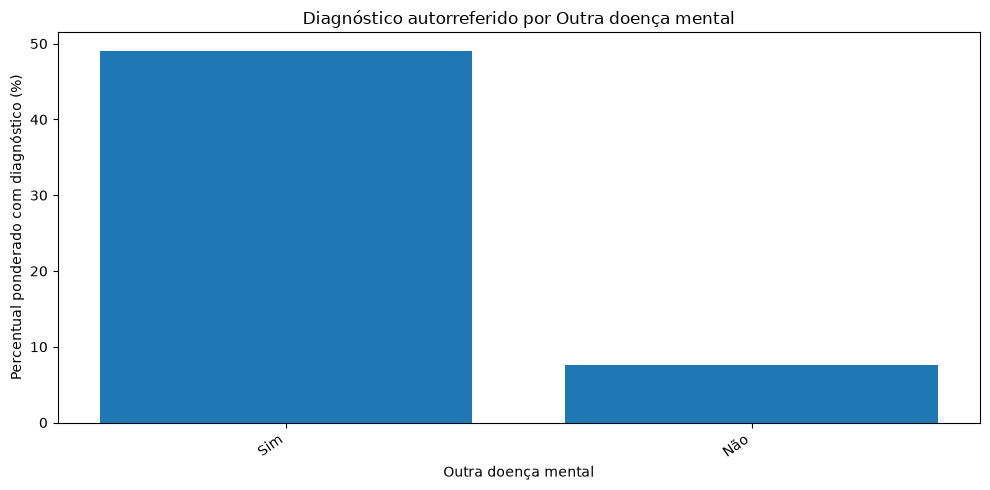

In [26]:
if variavel_escolhida in resultados_detalhados:
    tabela_grafico = resultados_detalhados[
        variavel_escolhida
    ]["ponderado"].sort_values(
        "Diagnóstico ponderado (%)",
        ascending=False,
    )

    plt.figure(figsize=(10, 5))

    plt.bar(
        tabela_grafico["Categoria"].astype(str),
        tabela_grafico["Diagnóstico ponderado (%)"],
    )

    plt.title(f"Diagnóstico autorreferido por {variavel_escolhida}")
    plt.xlabel(variavel_escolhida)
    plt.ylabel("Percentual ponderado com diagnóstico (%)")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()